1.首先利用Scikit-learn库生成make_moons数据并将数据划分为训练数据与测试数据两部分。\
from sklearn.datasets import make_moons \
x, y = make_moons(100, noise = 0.3) #产生样本数100、噪声为0.3的数据 \
from sklearn.model_selection import train_test_split \
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.4) #训练与测试数据划分（测试数据占40%）\
然后利用Scikit-learn库进行Logistic回归（训练数据）与分类预测（测试数据）：求取样本数为1000、噪声为0.1、0.3、0.5、0.8、1、1.5时的预测精度并画出预测精度随噪声的变化曲线；画出样本数为1000、噪声为0.3时的样本与分类界线。

不同噪声下的预测精度：
noise=0.1  accuracy=0.8725
noise=0.3  accuracy=0.8500
noise=0.5  accuracy=0.8025
noise=0.8  accuracy=0.7250
noise=1.0  accuracy=0.6800
noise=1.5  accuracy=0.6400


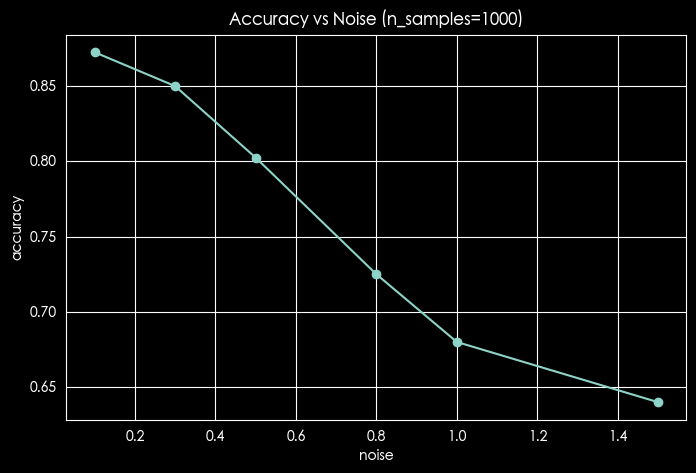

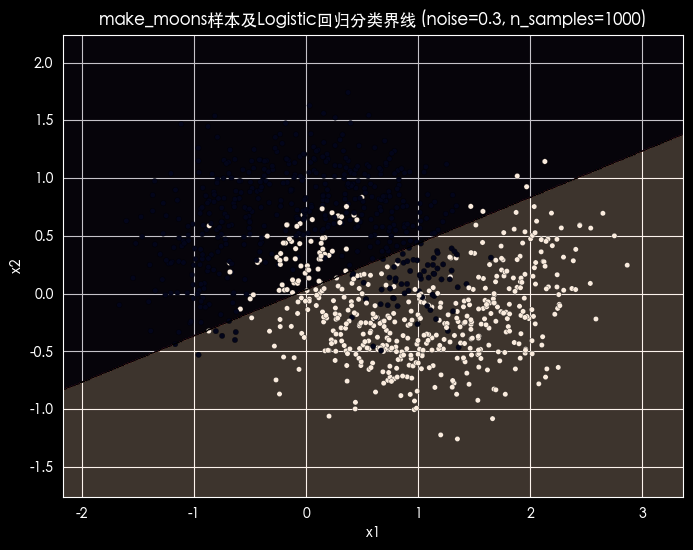

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import matplotlib

# 自动寻找系统中的中文字体
font = matplotlib.font_manager.FontProperties(fname="/System/Library/Fonts/STHeiti Light.ttc")

plt.rcParams['font.family'] = font.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 不同噪声水平
noise_list = [0.1, 0.3, 0.5, 0.8, 1.0, 1.5]
acc_list = []

# 计算不同噪声下的预测精度
for noise in noise_list:
    X, y = make_moons(n_samples=1000, noise=noise, random_state=42)
    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    acc_list.append(acc)

# 输出不同噪声下的预测精度
print("不同噪声下的预测精度：")
for n, a in zip(noise_list, acc_list):
    print(f"noise={n:<3}  accuracy={a:.4f}")

# 绘制预测精度随噪声变化曲线
plt.figure(figsize=(8, 5))
plt.plot(noise_list, acc_list, marker='o')
plt.xlabel("noise")
plt.ylabel("accuracy")
plt.title("Accuracy vs Noise (n_samples=1000)")
plt.grid(True)
plt.show()

# 样本数1000、噪声0.3时的样本与分类界线
X, y = make_moons(n_samples=1000, noise=0.3, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

# 构造网格点
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25)
plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1)
plt.scatter(X[:, 0], X[:, 1], c=y, s=15, edgecolors='k', linewidths=0.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("make_moons样本及Logistic回归分类界线 (noise=0.3, n_samples=1000)")
plt.show()

2.研究人员在研究肾细胞癌转移的有关病理因素时,收集了一批行根治性肾切除术患者的肾癌标本资料，现从中抽取16例病例资料做logistic回归分析，判断患者肾细胞癌是否转移。\
x1:确诊时患者的年龄(岁)\
x2:肾细胞癌血管内皮生长因子(VEGF),其阳性表述由低到高共3个等级(1-3)\
x3:肾细胞核癌组织内微血管数(MVC)\
x4:肾癌细胞核组织学分级,由低到高共4级(1-4)\
x5:肾细胞癌分期,由低到高共4期(1-4)\
y:肾细胞癌转移情况(有转移y=1;无转移y=0)。

In [5]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

# 构造数据
data = pd.DataFrame({
    'x1': [59, 36, 61, 58, 55, 61, 38, 42, 50, 58, 68, 25, 52, 31, 36, 42],
    'x2': [2, 1, 2, 3, 3, 1, 1, 1, 1, 3, 3, 2, 1, 1, 3, 1],
    'x3': [43.4, 57.2, 190.0, 128.0, 80.0, 94.4, 76.0, 240.0, 74.0, 68.6, 132.8, 94.6, 56.0, 47.8, 31.6, 66.2],
    'x4': [2, 1, 2, 4, 3, 2, 1, 3, 1, 2, 4, 4, 1, 2, 3, 2],
    'x5': [1, 1, 1, 3, 4, 1, 1, 2, 1, 2, 2, 3, 1, 1, 1, 1],
    'y':  [0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0]
})

X = data[['x1', 'x2', 'x3', 'x4', 'x5']]
y = data['y']

# 建立“标准化 + Logistic回归”模型
model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X, y)

# 预测
y_pred = model.predict(X)
y_prob = model.predict_proba(X)[:, 1]

# 输出结果
print("模型在样本上的预测准确率：", accuracy_score(y, y_pred))
print("混淆矩阵：")
print(confusion_matrix(y, y_pred))

lr = model.named_steps['lr']
print("截距：", lr.intercept_[0])
print("各变量系数：")
for name, coef in zip(['x1', 'x2', 'x3', 'x4', 'x5'], lr.coef_[0]):
    print(f"{name}: {coef:.6f}")

# 查看每个样本的预测结果
result = data.copy()
result['pred_prob'] = y_prob
result['pred_y'] = y_pred
print(result)

模型在样本上的预测准确率： 0.9375
混淆矩阵：
[[11  0]
 [ 1  4]]
截距： -1.2592184546560095
各变量系数：
x1: -1.019041
x2: 0.516570
x3: 0.380915
x4: 0.801148
x5: 0.825151
    x1  x2     x3  x4  x5  y  pred_prob  pred_y
0   59   2   43.4   2   1  0   0.039742       0
1   36   1   57.2   1   1  0   0.073831       0
2   61   2  190.0   2   1  0   0.089527       0
3   58   3  128.0   4   3  1   0.801324       1
4   55   3   80.0   3   4  1   0.806725       1
5   61   1   94.4   2   1  0   0.027171       0
6   38   1   76.0   1   1  0   0.071543       0
7   42   1  240.0   3   2  1   0.664469       1
8   50   1   74.0   1   1  0   0.027260       0
9   58   3   68.6   2   2  0   0.190258       0
10  68   3  132.8   4   2  0   0.427290       0
11  25   2   94.6   4   3  1   0.964992       1
12  52   1   56.0   1   1  0   0.020480       0
13  31   1   47.8   2   1  0   0.195853       0
14  36   3   31.6   3   1  1   0.499302       0
15  42   1   66.2   2   1  0   0.099999       0


3.“泰坦尼克号”的沉没是历史上最臭名昭著的海难之一,2224名乘客和机组人员中有1502人死亡。造成沉船事故的原因之一是没有足够的救生艇供乘客和机组人员使用，虽然在沉没中幸存了一些运气，但一些人比其他人更容易生存，如妇女、儿童和上层阶级。根据以下数据构建模型，来预测乘客是否能在悲剧中幸\
PassengerID:乘客ID\
Pclass:乘客等级，1表示Upper，2表示Middle，3表示Lower(乘客等级(1/2/3舱位))\
Sex:性别，1表女性，0表示男性\
Age:年龄\
SibSp:乘客在船上的配偶数量或兄弟姐妹数量\
Parch:乘客在船上的父母或子女数量\
Fare:票价\
Embarked: 登船港口数值越大表示距离越远\
Survived:是否获救，用1表示获救,用0表示没有获救

In [6]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

# 构造数据
data = pd.DataFrame({
    'PassengerId': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    'Pclass': [1,1,1,3,3,1,2,1,1,1,1,1,2,3,1,1,3,1,1,1],
    'Sex': [1,1,0,1,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0],
    'Age': [38,35,54,16,4,58,34,28,19,49,65,45,29,25,23,46,40,23,21,47],
    'SibSp': [1,1,0,0,1,0,0,0,3,1,0,1,0,0,3,1,1,0,0,0],
    'Parch': [0,0,0,0,1,0,0,0,2,0,1,0,0,0,2,0,1,1,1,0],
    'Fare': [71.2,53.1,51.9,79.2,16.7,26.6,13,35.5,263,76.7,62,83.4,10.5,7.65,263,61.2,15.5,63.4,77.3,52],
    'Embarked': [1,3,3,1,3,3,3,3,3,1,1,3,3,3,3,3,2,1,3,3],
    'Survived': [1,1,0,1,1,1,1,1,0,1,0,0,1,0,1,0,0,1,0,0]
})

X = data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = data['Survived']

# 建立“标准化 + Logistic回归”模型
model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X, y)

# 预测
y_pred = model.predict(X)
y_prob = model.predict_proba(X)[:, 1]

# 输出结果
print("模型在样本上的预测准确率：", accuracy_score(y, y_pred))
print("混淆矩阵：")
print(confusion_matrix(y, y_pred))

lr = model.named_steps['lr']
print("截距：", lr.intercept_[0])
print("各变量系数：")
for name, coef in zip(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], lr.coef_[0]):
    print(f"{name}: {coef:.6f}")

# 每个样本预测结果
result = data.copy()
result['pred_prob'] = y_prob
result['pred_y'] = y_pred
print(result)

模型在样本上的预测准确率： 0.95
混淆矩阵：
[[ 9  0]
 [ 1 10]]
截距： 0.509074364912517
各变量系数：
Pclass: -0.318760
Sex: 1.505529
Age: -0.841930
SibSp: -0.146774
Parch: -0.344424
Fare: -0.221529
Embarked: -0.443056
    PassengerId  Pclass  Sex  Age  SibSp  Parch    Fare  Embarked  Survived  \
0             1       1    1   38      1      0   71.20         1         1   
1             2       1    1   35      1      0   53.10         3         1   
2             3       1    0   54      0      0   51.90         3         0   
3             4       3    1   16      0      0   79.20         1         1   
4             5       3    1    4      1      1   16.70         3         1   
5             6       1    1   58      0      0   26.60         3         1   
6             7       2    0   34      0      0   13.00         3         1   
7             8       1    0   28      0      0   35.50         3         1   
8             9       1    0   19      3      2  263.00         3         0   
9            10     